# Save model, optimizer, and random state

Runnable locally on CPU or on a Cloud TPU VM.

- Checkpoint complete training state with Orbax and replay the next update.
- Explain Adam memory and continuation-key requirements.
- Restore known shapes/structure and validate version/data/configuration identity.
- Distinguish tested local synchronous saving from production durability.

A saved file is useful only if it contains what you need to continue. We’ll train a tiny regression model, save its weights, optimizer state, random key and step with Orbax, and check the next update after restoring. Then we’ll leave out pieces on purpose to see why they matter.

## The idea

A training checkpoint needs enough state to reproduce the next update. Weights alone do not capture optimizer memory or random-state ownership. Think of the checkpoint as the complete input to a future state transition.

## Save the inputs to the next update

Two runs with identical weights but different Adam moments can receive the same gradient and take different next steps. Different random keys can change augmentation or dropout before the gradient is computed.

The existing diagram merges state components into one snapshot. Its arrows mean membership in the snapshot, not a sequence in which parameters must be computed before moments or randomness. Every component must agree on the completed-step boundary.

Loading bytes successfully checks serialization. Test continuation by restoring into a fresh process and comparing the next transition with an uninterrupted run. Add iterator state through the data-recovery procedure that follows this lesson.

$$
\text{sha256}(\text{serialize}(\mathcal{C}_t)) = \text{sha256}(\text{deserialize}(\text{path}))
$$

### Pause and reason

What is stronger evidence than matching loaded weights?

<details><summary>Compare your reasoning</summary>

Match the next example identities, random state, optimizer update and resulting parameters. This tests the checkpoint's purpose rather than only its stored parameter values.

</details>

## Inventory everything the next step reads

step reads parameters, Adam memory and key_data, then consumes $x$ and $y$. It returns new parameters, new optimizer state, the continuation key and an incremented step count. Adam includes first and second gradient moments plus a count for bias correction. Reinitializing it from saved parameters discards those moments.

The noisy targets deliberately make randomness matter, so a key reset cannot pass invisibly. We serialize key_data as uint32 words and explicitly reconstruct a threefry2x32 key. Raw words alone do not identify every possible PRNG implementation; the contract records that choice. The learning rate and Adam identity are recorded because optimizer state does not encode every update rule.

```text
params + Adam moments/count + continuation key + step
                 + next batch → next update
```

## Save to a real local checkpoint directory

StandardCheckpointer may perform asynchronous work internally. We call wait_until_finished immediately after save and before restore. save writes an actual Orbax checkpoint under an absolute path in a TemporaryDirectory, then restore reads it back. Calling save alone is not our completion claim. No restore is accepted just because the directory exists: we compare the complete state and its next transition. All files are removed when the temporary workspace is cleaned up; copy a learner-run checkpoint to your chosen evidence folder if you want to keep it.

This example does not implement a cloud retention policy, an asynchronous manager, multi-process synchronization or protection against every storage failure. A successful synchronous local save demonstrates the tested library path and numerical replay. It is not evidence of production durability under a machine or disk failure.

## Restore into an explicit state template

The target supplies a known model dictionary and the Adam namedtuple/pytree structure initialized by the same optimizer definition. That prevents relying on an untyped collection of arrays as if it were a complete model. We then compare pytree structure and every leaf, including the continuation key and count.

The compatibility contract is encoded as JSON bytes in a fixed-size uint8 buffer with a separate length. This keeps the restore target shapes known without pickling Python objects. The 4096-byte capacity is a tutorial simplification: oversized metadata fails explicitly. For a different model shape or optimizer, define a migration deliberately rather than claiming a generic restore.

## Version and data checks belong to the application

The payload includes schema version, package versions, learning rate, optimizer identity, key implementation and a digest of this exact input/target pair. validate_contract rejects any mismatch before continuing training. A checksum can identify changed data; it does not repair it or authenticate a hostile checkpoint.

The strongest local recovery check is the next loss and full updated state against an uninterrupted transition at the same boundary. We use float32 and allclose with `rtol=1e-6`, `atol=1e-7` for numerical leaves. Keys and counters are integer state whose expected values should remain identical. Changing hardware, reductions or library versions needs new validation; this lesson establishes only the tested CPU environment.

## Prepare the data and state

Create main.py in your course workspace. Use the tested course environment and add this block first.

In [1]:
# Step 1 — Prepare the data and state: This setup makes the dataset and software assumptions explicit.
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update("jax_platforms","cpu")
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
import tempfile
import json
import hashlib
from pathlib import Path
# Configure or step the Optax optimizer state (`tx`).
tx = optax.adam(0.05)
# Function `initial_state()` implementing this stage's computation:
def initial_state():
    # Construct `params` via `{"weight":jnp.array(0.,jnp.float32),"bias":jnp.array...`
    params = {"weight":jnp.array(0.,jnp.float32),"bias":jnp.array(0.,jnp.float32)}
    # Return `{'params': params, 'optimizer': tx.init(params), 'key_data': jax.random.key_data(jax.random.key(7, impl='threefry2x32')), 'step': jnp.array(0, jnp.int32)}` to the caller.
    return {"params":params,"optimizer":tx.init(params),
            "key_data":jax.random.key_data(jax.random.key(7,impl="threefry2x32")),
            "step":jnp.array(0,jnp.int32)}
# Function `pack_bytes(raw, capacity)` implementing this stage's computation:
def pack_bytes(raw,capacity=4096):
    # Guard input contract (`len(raw) > capacity`) and fail fast if violated.
    if len(raw)>capacity:
        raise ValueError("Snapshot exceeds tutorial fixed-byte capacity")
    # Allocate initialized array `buffer` with the specified shape and dtype.
    buffer = np.zeros(capacity,dtype=np.uint8)
    # Run `np.frombuffer` to compute `buffer[:len(raw)]`.
    buffer[:len(raw)] = np.frombuffer(raw,dtype=np.uint8)
    # Return `{'buffer': buffer, 'length': np.array(len(raw), dtype=np.int32)}` to the caller.
    return {"buffer":buffer,"length":np.array(len(raw),dtype=np.int32)}
# Function `unpack_bytes(packed)` implementing this stage's computation:
def unpack_bytes(packed):
    # Evaluate `packed['length']` and convert the result into Python scalar/collection `length`.
    length = int(packed["length"])
    # Guard input contract (`not 0 <= length <= len(packed['buffer'])`) and fail fast if violated.
    if not 0 <= length <= len(packed["buffer"]):
        raise ValueError("Invalid snapshot length")
    # Return `np.asarray(packed['buffer'], dtype=np.uint8)[:length].tobytes()` to the caller.
    return np.asarray(packed["buffer"],dtype=np.uint8)[:length].tobytes()
# Function `same_tree(left, right)` implementing this stage's computation:
def same_tree(left,right):
    # Assert invariant `jax.tree.structure(left)==jax.tree.structure(right)` holds
    assert jax.tree.structure(left)==jax.tree.structure(right)
    # Iterate over `(a, b)` to step through the computation:
    for a,b in zip(jax.tree.leaves(left),jax.tree.leaves(right)):
        # Convert `(host_a, host_b)` to a host NumPy array for inspection or verification.
        host_a,host_b = np.asarray(a),np.asarray(b)
        # Check tensor shape invariant: `host_a.shape==host_b.shape and host_a.dtype==host_b.dtype`
        assert host_a.shape==host_b.shape and host_a.dtype==host_b.dtype
        # Branch on condition `np.issubdtype(host_a.dtype, np.integer)`:
        if np.issubdtype(host_a.dtype,np.integer):
            np.testing.assert_array_equal(host_a,host_b)
        else:
            np.testing.assert_allclose(host_a,host_b,rtol=1e-6,atol=1e-7)
# Define `step(state, x, y)` to evaluate the objective and its automatic derivatives:
def step(state,x,y):
    # Sample deterministic random values into `key` using an explicit PRNG key.
    key = jax.random.wrap_key_data(state["key_data"],impl="threefry2x32")
    # Create or split explicit PRNG key(s) (`(next_key, sample_key)`) for reproducible randomness.
    next_key,sample_key = jax.random.split(key)
    # Sample deterministic random values into `target_noise` using an explicit PRNG key.
    target_noise = 0.01*jax.random.normal(sample_key,y.shape)
    # Function `objective(params)` implementing this stage's computation:
    def objective(params):
        # Compute `residual` from `params["weight"]*x+params["bias"]-(y+target_noise)`
        residual = params["weight"]*x+params["bias"]-(y+target_noise)
        # Return `jnp.mean(residual ** 2)` to the caller.
        return jnp.mean(residual**2)
    # Evaluate both scalar loss and parameter gradients in one pass (`(value, gradient)`).
    value,gradient = jax.value_and_grad(objective)(state["params"])
    # Run `tx.update` to compute `(updates, opt_state)`.
    updates,opt_state = tx.update(gradient,state["optimizer"],state["params"])
    # Initialize explicit deterministic PRNG key `next_state`.
    next_state = {"params":optax.apply_updates(state["params"],updates),
                  "optimizer":opt_state,"key_data":jax.random.key_data(next_key),
                  "step":state["step"]+1}
    # Return `(next_state, value)` to the caller.
    return next_state,value
# Function `package_versions()` implementing this stage's computation:
def package_versions():
    # Import importlib.metadata for this computation.
    import importlib.metadata
    # Return `{name: importlib.metadata.version(name) for name in ('jax', 'numpy', 'optax', 'orbax-checkpoint')}` to the caller.
    return {name:importlib.metadata.version(name) for name in ("jax","numpy","optax","orbax-checkpoint")}
# Function `encode_contract(contract)` implementing this stage's computation:
def encode_contract(contract):
    # Return `pack_bytes(json.dumps(contract, sort_keys=True).encode())` to the caller.
    return pack_bytes(json.dumps(contract,sort_keys=True).encode())
# Function `validate_contract(saved, expected)` implementing this stage's computation:
def validate_contract(saved,expected):
    # Read or serialize artifact data on disk (`actual`).
    actual = json.loads(unpack_bytes(saved))
    # Guard input contract (`actual != expected`) and fail fast if violated.
    if actual != expected:
        raise ValueError("Checkpoint contract differs: verify dataset, optimizer configuration, key implementation and package versions")
# Run `tempfile.TemporaryDirectory` to compute `workspace`.
workspace = tempfile.TemporaryDirectory()
# Read or serialize artifact data on disk (`root`).
root = Path(workspace.name)

This setup makes the dataset and software assumptions explicit. No external dataset or accelerator is required.

## Build the pipeline or state transition

Append this block to the same file; follow the named state objects through each function.

In [2]:
# Step 2 — Build the pipeline or state transition: The function boundaries expose which inputs determine the next...
# Construct `x` via `jnp.array([0.,0.5,1.],dtype=jnp.float32)`
x = jnp.array([0.,0.5,1.],dtype=jnp.float32)
# Compute `y` from `2*x-1`
y = 2*x-1
# Convert `contract` to a host NumPy array for inspection or verification.
contract = {"schema":1,"learning_rate":0.05,"optimizer":"adam",
            "key_impl":"threefry2x32","versions":package_versions(),
            "data_sha256":hashlib.sha256(np.asarray(x).tobytes()+np.asarray(y).tobytes()).hexdigest()}
# Run `initial_state` to compute `state`.
state = initial_state()
# Repeat the update loop over `range(3)` steps:
for _ in range(3):
    # Run `step` to compute `(state, _)`.
    state,_ = step(state,x,y)
# Compute `checkpoint_path` from `root/"step_3"`
checkpoint_path = root/"step_3"
# Compute `payload` from `{"training":state,"contract":encode_contract(contract)}`
payload = {"training":state,"contract":encode_contract(contract)}
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as checkpointer:
    # Run `checkpointer.save` to perform the next check or state transition.
    checkpointer.save(checkpoint_path,payload)
    # Run `checkpointer.wait_until_finished` to perform the next check or state transition.
    checkpointer.wait_until_finished()
    # Run `checkpointer.restore` to compute `restored`.
    restored = checkpointer.restore(checkpoint_path,target={"training":initial_state(),"contract":encode_contract(contract)})
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored["contract"],contract)

The function boundaries expose which inputs determine the next output and which state must be preserved.

## Run the comparison

Append the checks, save main.py and run python main.py. Predict what should agree before running.

In [3]:
# Step 3 — Run the comparison: The comparison checks the next behavior, not merely whether a save...
same_tree(state,restored["training"])
# Run `step` to compute `(expected_next, expected_loss)`.
expected_next,expected_loss = step(state,x,y)
# Run `step` to compute `(restored_next, restored_loss)`.
restored_next,restored_loss = step(restored["training"],x,y)
# Run `same_tree` to perform the next check or state transition.
same_tree(expected_next,restored_next)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(expected_loss),np.asarray(restored_loss),rtol=1e-6)
# Assert invariant `int(restored_next["step"])==4` holds
assert int(restored_next["step"])==4
# Print the observed values to compare against the expected result.
print("Restored step:",int(restored["training"]["step"]))
# Print diagnostic summary of the computed outputs.
print("Optimizer count:",int(restored["training"]["optimizer"][0].count))
# Print diagnostic summary of the computed outputs.
print("Next update and loss agree; checkpoint exists:",checkpoint_path.exists())

Restored step: 3
Optimizer count: 3
Next update and loss agree; checkpoint exists: True


The comparison checks the next behavior, not merely whether a save call succeeded.

## Run the example

In [4]:
# Step 1 — Prepare the data and state: This setup makes the dataset and software assumptions explicit.
# Import jax for this computation.
import jax
# Update state in place with the new values.
jax.config.update("jax_platforms","cpu")
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
import tempfile
import json
import hashlib
from pathlib import Path
# Configure or step the Optax optimizer state (`tx`).
tx = optax.adam(0.05)
# Function `initial_state()` implementing this stage's computation:
def initial_state():
    # Construct `params` via `{"weight":jnp.array(0.,jnp.float32),"bias":jnp.array...`
    params = {"weight":jnp.array(0.,jnp.float32),"bias":jnp.array(0.,jnp.float32)}
    # Return `{'params': params, 'optimizer': tx.init(params), 'key_data': jax.random.key_data(jax.random.key(7, impl='threefry2x32')), 'step': jnp.array(0, jnp.int32)}` to the caller.
    return {"params":params,"optimizer":tx.init(params),
            "key_data":jax.random.key_data(jax.random.key(7,impl="threefry2x32")),
            "step":jnp.array(0,jnp.int32)}
# Function `pack_bytes(raw, capacity)` implementing this stage's computation:
def pack_bytes(raw,capacity=4096):
    # Guard input contract (`len(raw) > capacity`) and fail fast if violated.
    if len(raw)>capacity:
        raise ValueError("Snapshot exceeds tutorial fixed-byte capacity")
    # Allocate initialized array `buffer` with the specified shape and dtype.
    buffer = np.zeros(capacity,dtype=np.uint8)
    # Run `np.frombuffer` to compute `buffer[:len(raw)]`.
    buffer[:len(raw)] = np.frombuffer(raw,dtype=np.uint8)
    # Return `{'buffer': buffer, 'length': np.array(len(raw), dtype=np.int32)}` to the caller.
    return {"buffer":buffer,"length":np.array(len(raw),dtype=np.int32)}
# Function `unpack_bytes(packed)` implementing this stage's computation:
def unpack_bytes(packed):
    # Evaluate `packed['length']` and convert the result into Python scalar/collection `length`.
    length = int(packed["length"])
    # Guard input contract (`not 0 <= length <= len(packed['buffer'])`) and fail fast if violated.
    if not 0 <= length <= len(packed["buffer"]):
        raise ValueError("Invalid snapshot length")
    # Return `np.asarray(packed['buffer'], dtype=np.uint8)[:length].tobytes()` to the caller.
    return np.asarray(packed["buffer"],dtype=np.uint8)[:length].tobytes()
# Function `same_tree(left, right)` implementing this stage's computation:
def same_tree(left,right):
    # Assert invariant `jax.tree.structure(left)==jax.tree.structure(right)` holds
    assert jax.tree.structure(left)==jax.tree.structure(right)
    # Iterate over `(a, b)` to step through the computation:
    for a,b in zip(jax.tree.leaves(left),jax.tree.leaves(right)):
        # Convert `(host_a, host_b)` to a host NumPy array for inspection or verification.
        host_a,host_b = np.asarray(a),np.asarray(b)
        # Check tensor shape invariant: `host_a.shape==host_b.shape and host_a.dtype==host_b.dtype`
        assert host_a.shape==host_b.shape and host_a.dtype==host_b.dtype
        # Branch on condition `np.issubdtype(host_a.dtype, np.integer)`:
        if np.issubdtype(host_a.dtype,np.integer):
            np.testing.assert_array_equal(host_a,host_b)
        else:
            np.testing.assert_allclose(host_a,host_b,rtol=1e-6,atol=1e-7)
# Define `step(state, x, y)` to evaluate the objective and its automatic derivatives:
def step(state,x,y):
    # Sample deterministic random values into `key` using an explicit PRNG key.
    key = jax.random.wrap_key_data(state["key_data"],impl="threefry2x32")
    # Create or split explicit PRNG key(s) (`(next_key, sample_key)`) for reproducible randomness.
    next_key,sample_key = jax.random.split(key)
    # Sample deterministic random values into `target_noise` using an explicit PRNG key.
    target_noise = 0.01*jax.random.normal(sample_key,y.shape)
    # Function `objective(params)` implementing this stage's computation:
    def objective(params):
        # Compute `residual` from `params["weight"]*x+params["bias"]-(y+target_noise)`
        residual = params["weight"]*x+params["bias"]-(y+target_noise)
        # Return `jnp.mean(residual ** 2)` to the caller.
        return jnp.mean(residual**2)
    # Evaluate both scalar loss and parameter gradients in one pass (`(value, gradient)`).
    value,gradient = jax.value_and_grad(objective)(state["params"])
    # Run `tx.update` to compute `(updates, opt_state)`.
    updates,opt_state = tx.update(gradient,state["optimizer"],state["params"])
    # Initialize explicit deterministic PRNG key `next_state`.
    next_state = {"params":optax.apply_updates(state["params"],updates),
                  "optimizer":opt_state,"key_data":jax.random.key_data(next_key),
                  "step":state["step"]+1}
    # Return `(next_state, value)` to the caller.
    return next_state,value
# Function `package_versions()` implementing this stage's computation:
def package_versions():
    # Import importlib.metadata for this computation.
    import importlib.metadata
    # Return `{name: importlib.metadata.version(name) for name in ('jax', 'numpy', 'optax', 'orbax-checkpoint')}` to the caller.
    return {name:importlib.metadata.version(name) for name in ("jax","numpy","optax","orbax-checkpoint")}
# Function `encode_contract(contract)` implementing this stage's computation:
def encode_contract(contract):
    # Return `pack_bytes(json.dumps(contract, sort_keys=True).encode())` to the caller.
    return pack_bytes(json.dumps(contract,sort_keys=True).encode())
# Function `validate_contract(saved, expected)` implementing this stage's computation:
def validate_contract(saved,expected):
    # Read or serialize artifact data on disk (`actual`).
    actual = json.loads(unpack_bytes(saved))
    # Guard input contract (`actual != expected`) and fail fast if violated.
    if actual != expected:
        raise ValueError("Checkpoint contract differs: verify dataset, optimizer configuration, key implementation and package versions")
# Run `tempfile.TemporaryDirectory` to compute `workspace`.
workspace = tempfile.TemporaryDirectory()
# Read or serialize artifact data on disk (`root`).
root = Path(workspace.name)

# Step 2 — Build the pipeline or state transition: The function boundaries expose which inputs determine the next...
# Construct `x` via `jnp.array([0.,0.5,1.],dtype=jnp.float32)`
x = jnp.array([0.,0.5,1.],dtype=jnp.float32)
# Compute `y` from `2*x-1`
y = 2*x-1
# Convert `contract` to a host NumPy array for inspection or verification.
contract = {"schema":1,"learning_rate":0.05,"optimizer":"adam",
            "key_impl":"threefry2x32","versions":package_versions(),
            "data_sha256":hashlib.sha256(np.asarray(x).tobytes()+np.asarray(y).tobytes()).hexdigest()}
# Run `initial_state` to compute `state`.
state = initial_state()
# Repeat the update loop over `range(3)` steps:
for _ in range(3):
    # Run `step` to compute `(state, _)`.
    state,_ = step(state,x,y)
# Compute `checkpoint_path` from `root/"step_3"`
checkpoint_path = root/"step_3"
# Compute `payload` from `{"training":state,"contract":encode_contract(contract)}`
payload = {"training":state,"contract":encode_contract(contract)}
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as checkpointer:
    # Run `checkpointer.save` to perform the next check or state transition.
    checkpointer.save(checkpoint_path,payload)
    # Run `checkpointer.wait_until_finished` to perform the next check or state transition.
    checkpointer.wait_until_finished()
    # Run `checkpointer.restore` to compute `restored`.
    restored = checkpointer.restore(checkpoint_path,target={"training":initial_state(),"contract":encode_contract(contract)})
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored["contract"],contract)

# Step 3 — Run the comparison: The comparison checks the next behavior, not merely whether a save...
same_tree(state,restored["training"])
# Run `step` to compute `(expected_next, expected_loss)`.
expected_next,expected_loss = step(state,x,y)
# Run `step` to compute `(restored_next, restored_loss)`.
restored_next,restored_loss = step(restored["training"],x,y)
# Run `same_tree` to perform the next check or state transition.
same_tree(expected_next,restored_next)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(expected_loss),np.asarray(restored_loss),rtol=1e-6)
# Assert invariant `int(restored_next["step"])==4` holds
assert int(restored_next["step"])==4
# Print the observed values to compare against the expected result.
print("Restored step:",int(restored["training"]["step"]))
# Print diagnostic summary of the computed outputs.
print("Optimizer count:",int(restored["training"]["optimizer"][0].count))
# Print diagnostic summary of the computed outputs.
print("Next update and loss agree; checkpoint exists:",checkpoint_path.exists())

Restored step: 3
Optimizer count: 3
Next update and loss agree; checkpoint exists: True


Expected: Saved/restored training step $3$ and Adam count $3$; next step $4$, loss and full state agree within stated tolerances. Actual checkpoint path is temporary.

## Parameter parity: uninterrupted step vs. Orbax-restored step

Predict: Predict the maximum absolute difference between the uninterrupted next state and the Orbax-restored next state.

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compare parameter leaf norms between `expected_next` and `restored_next`:
saved_norms = [float(jnp.linalg.norm(a)) for a in jax.tree.leaves(expected_next['params'])]
restored_norms = [float(jnp.linalg.norm(a)) for a in jax.tree.leaves(restored_next['params'])]
visual_data = {'kind': 'bar', 'x': list(range(len(saved_norms))), 'labels': [f'leaf {i}' for i in range(len(saved_norms))], 'xlabel': 'checkpoint parameter leaf index', 'ylabel': 'L2 norm', 'series': [{'label': 'uninterrupted step', 'y': saved_norms}, {'label': 'restored from Orbax', 'y': restored_norms}]}

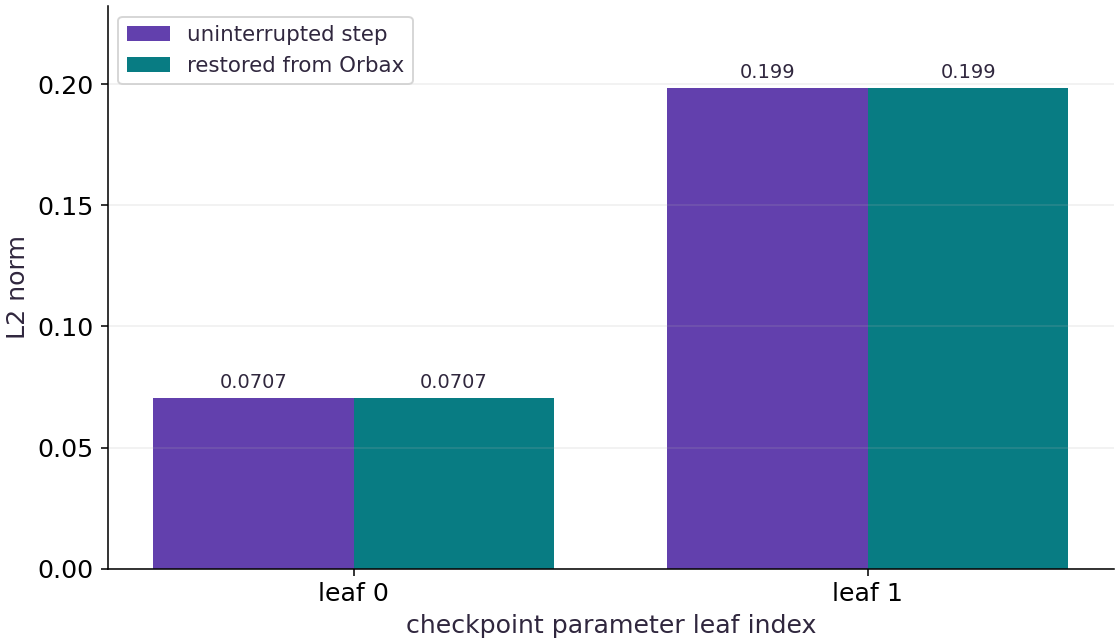

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Adjacent bars for each parameter leaf have identical L2 norms between the uninterrupted run and the Orbax-restored run.

### Connect it to the computation

Verifying exact leaf equality after deserialization guarantees that the restored checkpoint reproduces the exact next training step.

## Model-only restoration loses Adam history

Predict: With the same parameters, key and input, will a freshly initialized optimizer reproduce the next update?

In [7]:
# Experiment — Model-only restoration loses Adam history: Saved weights give the same pre-update predictions but not...
model_only = dict(restored["training"])
# Run `tx.init` to compute `model_only['optimizer']`.
model_only["optimizer"] = tx.init(model_only["params"])
# Run `step` to compute `(wrong_next, _)`.
wrong_next,_ = step(model_only,x,y)
# Assert that `any(not np.allclose(np.asarray(a),np.asarray(b),rtol=1e-6,atol=1e-7) for a,b in zip(jax.tree`.
assert any(not np.allclose(np.asarray(a),np.asarray(b),rtol=1e-6,atol=1e-7) for a,b in zip(jax.tree.leaves(wrong_next["params"]),jax.tree.leaves(expected_next["params"])))
# Assert invariant `int(wrong_next["optimizer"][0].count)==1` holds
assert int(wrong_next["optimizer"][0].count)==1
# Print the observed values to compare against the expected result.
print("Model-only checkpoint produces a different Adam update")

Model-only checkpoint produces a different Adam update


Expected: Fresh optimizer count becomes $1$ and parameters differ from the full-state continuation.

Saved weights give the same pre-update predictions but not necessarily the same optimizer transition.

## Reset the random stream

Predict: What changes if parameters and Adam memory restore correctly but the key resets to seed seven?

In [8]:
# Experiment — Reset the random stream: A seed identifies the initial stream; a saved continuation key...
reset_random = dict(restored["training"])
# Run `initial_state` to compute `reset_random['key_data']`.
reset_random["key_data"] = initial_state()["key_data"]
# Run `step` to compute `(reset_next, reset_loss)`.
reset_next,reset_loss = step(reset_random,x,y)
# Assert that `not np.isclose(float(reset_loss),float(expected_loss),rtol=1e-6,atol=1e-7)`.
assert not np.isclose(float(reset_loss),float(expected_loss),rtol=1e-6,atol=1e-7)
# Assert invariant `not np.array_equal(np.asarray(reset_next["key_data"])` holds
assert not np.array_equal(np.asarray(reset_next["key_data"]),np.asarray(expected_next["key_data"]))
# Print the observed values to compare against the expected result.
print("Reset key changes the noisy objective and continuation stream")

Reset key changes the noisy objective and continuation stream


Expected: The noisy objective and continuation key differ.

A seed identifies the initial stream; a saved continuation key identifies the current boundary.

## Your exercise

Advance to step five, save to a new directory, restore and verify step six against uninterrupted execution.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `step(...)` — Call `step` with your updated parameters or inputs from this lesson's workspace.
- `ocp.StandardCheckpointer(...)` — Call `ocp.StandardCheckpointer` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Repeat the update loop over `range(2)` steps:
2. Run `step` to compute `(later, _)`.
3. Enter `ocp.StandardCheckpointer()` context block:
4. Read or serialize artifact data on disk (`later_path`).
5. Run `cp.save` to perform the next check or state transition.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Advance to step five, save to a new directory, restore and verify step...
later = ...  # TODO: compute later
# Repeat the update loop over `range(2)` steps:
# Run `step` to compute `(later, _)`.
for _ in range(2):later,_=step(later,x,y)
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Read or serialize artifact data on disk (`later_path`).
    later_path = Path(...)  # TODO: compute later_path
    # Run `cp.save` to perform the next check or state transition.
    cp.save(later_path,{"training":later,"contract":encode_contract(contract)})
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Run `cp.restore` to compute `recovered`.
    recovered = cp.restore(...)  # TODO: compute recovered
# Run `validate_contract` to perform the next check or state transition.
validate_contract(recovered["contract"],contract)
# Run `step` to compute `(left, _)`.
# Run `step` to compute `(right, _)`.
left,_ = step(...)  # TODO: compute left,_
right,_ = step(...)  # TODO: compute right,_
# Run `same_tree` to perform the next check or state transition.
same_tree(left,right)
# Assert invariant `int(right["step"])==6` holds
assert int(right["step"])  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Advance to step five, save to a new directory, restore and verify step...
# later = ...  # TODO: compute later
# Repeat the update loop over `range(2)` steps:
# Run `step` to compute `(later, _)`.
# for _ in range(2):later,_=step(later,x,y)
# Enter `ocp.StandardCheckpointer()` context block:
# with ocp.StandardCheckpointer() as cp:
    # Read or serialize artifact data on disk (`later_path`).
#     later_path = Path(...)  # TODO: compute later_path
    # Run `cp.save` to perform the next check or state transition.
#     cp.save(later_path,{"training":later,"contract":encode_contract(contract)})
    # Run `cp.wait_until_finished` to perform the next check or state transition.
#     cp.wait_until_finished()
    # Run `cp.restore` to compute `recovered`.
#     recovered = cp.restore(...)  # TODO: compute recovered
# Run `validate_contract` to perform the next check or state transition.
# validate_contract(recovered["contract"],contract)
# Run `step` to compute `(left, _)`.
# Run `step` to compute `(right, _)`.
# left,_ = step(...)  # TODO: compute left,_
# right,_ = step(...)  # TODO: compute right,_
# Run `same_tree` to perform the next check or state transition.
# same_tree(left,right)
# Assert invariant `int(right["step"])==6` holds
# assert int(right["step"])  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Advance to step five, save to a new directory, restore and verify step...
later = state
# Repeat the update loop over `range(2)` steps:
# Run `step` to compute `(later, _)`.
for _ in range(2):later,_=step(later,x,y)
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Read or serialize artifact data on disk (`later_path`).
    later_path = Path(tempfile.mkdtemp(dir=root))/"step_5"
    # Run `cp.save` to perform the next check or state transition.
    cp.save(later_path,{"training":later,"contract":encode_contract(contract)})
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Run `cp.restore` to compute `recovered`.
    recovered = cp.restore(later_path,target={"training":initial_state(),"contract":encode_contract(contract)})
# Run `validate_contract` to perform the next check or state transition.
validate_contract(recovered["contract"],contract)
# Run `step` to compute `(left, _)`.
# Run `step` to compute `(right, _)`.
left,_=step(later,x,y)
right,_=step(recovered["training"],x,y)
# Run `same_tree` to perform the next check or state transition.
same_tree(left,right)
# Assert invariant `int(right["step"])==6` holds
assert int(right["step"])==6

## Show what weights-only recovery loses · Transfer

Keep the restored parameters but reset Adam’s memory. Compare the next update with the full-state restore. Keep data and random state identical so the optimizer memory is the only changed factor.

Hint: Create a new mapping and replace only its optimizer entry.

### How to write: Show what weights-only recovery loses — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Evaluate `full, optimizer=tx.init(full['params'])` and convert the result into Python scalar/collection `weights_only`.
2. Run `step` to compute `(full_next, _)`.
3. Run `step` to compute `(reset_next, _)`.
4. Assert invariant `int(full_next['optimizer'][0].count)==4` holds
5. Assert invariant `int(reset_next['optimizer'][0].count)==1` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Show what weights-only recovery loses (Transfer): A checkpoint can return plausible predictions yet fail to...
full = ...  # TODO: compute full
# Evaluate `full, optimizer=tx.init(full['params'])` and convert the result into Python scalar/collection `weights_only`.
weights_only = dict(...)  # TODO: compute weights_only
# Run `step` to compute `(full_next, _)`.
full_next,_ = step(...)  # TODO: compute full_next,_
# Run `step` to compute `(reset_next, _)`.
reset_next,_ = step(...)  # TODO: compute reset_next,_
# Assert invariant `int(full_next['optimizer'][0].count)==4` holds
assert int(full_next['optimizer'][0].count)  # TODO: complete assertion check
# Assert invariant `int(reset_next['optimizer'][0].count)==1` holds
assert int(reset_next['optimizer'][0].count)  # TODO: complete assertion check
# Assert that `any(not np.allclose(a,b,rtol=1e-6,atol=1e-7) for a,b in zip(jax.tree.leaves(full_next['param`.
assert any(not np.allclose(a,b,rtol=1e-6,atol=1e-7) for a,b  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Full restore Adam count: 4; reset memory count: 1; next parameters differ.')
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Show what weights-only recovery loses (Transfer): A checkpoint can return plausible predictions yet fail to...
# full = ...  # TODO: compute full
# Evaluate `full, optimizer=tx.init(full['params'])` and convert the result into Python scalar/collection `weights_only`.
# weights_only = dict(...)  # TODO: compute weights_only
# Run `step` to compute `(full_next, _)`.
# full_next,_ = step(...)  # TODO: compute full_next,_
# Run `step` to compute `(reset_next, _)`.
# reset_next,_ = step(...)  # TODO: compute reset_next,_
# Assert invariant `int(full_next['optimizer'][0].count)==4` holds
# assert int(full_next['optimizer'][0].count)  # TODO: complete assertion check
# Assert invariant `int(reset_next['optimizer'][0].count)==1` holds
# assert int(reset_next['optimizer'][0].count)  # TODO: complete assertion check
# Assert that `any(not np.allclose(a,b,rtol=1e-6,atol=1e-7) for a,b in zip(jax.tree.leaves(full_next['param`.
# assert any(not np.allclose(a,b,rtol=1e-6,atol=1e-7) for a,b  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Full restore Adam count: 4; reset memory count: 1; next parameters differ.')

## Reference reasoning

A checkpoint can return plausible predictions yet fail to resume the original training trajectory. Adam’s moments and count affect the next update even when the weights and batch match.

In [12]:
# Show what weights-only recovery loses (Transfer): A checkpoint can return plausible predictions yet fail to...
full=restored['training']
# Evaluate `full, optimizer=tx.init(full['params'])` and convert the result into Python scalar/collection `weights_only`.
weights_only=dict(full,optimizer=tx.init(full['params']))
# Run `step` to compute `(full_next, _)`.
full_next,_=step(full,x,y)
# Run `step` to compute `(reset_next, _)`.
reset_next,_=step(weights_only,x,y)
# Assert invariant `int(full_next['optimizer'][0].count)==4` holds
assert int(full_next['optimizer'][0].count)==4
# Assert invariant `int(reset_next['optimizer'][0].count)==1` holds
assert int(reset_next['optimizer'][0].count)==1
# Assert that `any(not np.allclose(a,b,rtol=1e-6,atol=1e-7) for a,b in zip(jax.tree.leaves(full_next['param`.
assert any(not np.allclose(a,b,rtol=1e-6,atol=1e-7) for a,b in zip(jax.tree.leaves(full_next['params']),jax.tree.leaves(reset_next['params'])))
# Print the observed values to compare against the expected result.
print('Full restore Adam count: 4; reset memory count: 1; next parameters differ.')

Full restore Adam count: 4; reset memory count: 1; next parameters differ.


## Reject an incompatible update configuration · Challenge

Attempt to restore the contract under learning rate $0.1$. Show the rejection, then validate the original configuration. Also inspect shape and dtype equality of restored parameter leaves.

Hint: A compatible pytree can still represent the wrong update rule.

### How to write: Reject an incompatible update configuration — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `configuration(...)` — Call `configuration` with your updated parameters or inputs from this lesson's workspace.
- `validate_contract(...)` — Call `validate_contract` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Run the boundary check and catch the expected exception:
2. Run `validate_contract` to perform the next check or state transition.
3. Iterate over `(a, b)` to step through the computation:
4. Check tensor shape invariant: `a.shape==b.shape and a.dtype==b.dtype`
5. Integer PRNG words must be checked exactly, not with relative float tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Reject an incompatible update configuration (Challenge): Array restoration does not verify that a learning rate, data...
changed_contract = dict(...)  # TODO: compute changed_contract
# Run the boundary check and catch the expected exception:
try:
    validate_contract(restored["contract"],changed_contract)
except ValueError:
    print("Expected changed configuration rejection")
else:
    raise AssertionError("Expected contract mismatch")
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored["contract"],contract)
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(jax.tree.leaves(state["params"]),jax.tree.leaves(restored["training"]["params"])):
    # Check tensor shape invariant: `a.shape==b.shape and a.dtype==b.dtype`
    assert a.shape  # TODO: complete assertion check
# Integer PRNG words must be checked exactly, not with relative float tolerance.
changed_key = dict(...)  # TODO: compute changed_key
# Compute `changed_key["key_data"]` from `state["key_data"].at[0].add(np.uint32(1))`
changed_key["key_data"] = ...  # TODO: compute changed_key["key_data"]
# Run the boundary check and catch the expected exception:
try:
    same_tree(state,changed_key)
except AssertionError:
    print("Expected exact key-data mismatch")
else:
    raise AssertionError("Expected changed PRNG word rejection")
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Reject an incompatible update configuration (Challenge): Array restoration does not verify that a learning rate, data...
# changed_contract = dict(...)  # TODO: compute changed_contract
# Run the boundary check and catch the expected exception:
# try:
#     validate_contract(restored["contract"],changed_contract)
# except ValueError:
#     print("Expected changed configuration rejection")
# else:
#     raise AssertionError("Expected contract mismatch")
# Run `validate_contract` to perform the next check or state transition.
# validate_contract(restored["contract"],contract)
# Iterate over `(a, b)` to step through the computation:
# for a,b in zip(jax.tree.leaves(state["params"]),jax.tree.leaves(restored["training"]["params"])):
    # Check tensor shape invariant: `a.shape==b.shape and a.dtype==b.dtype`
#     assert a.shape  # TODO: complete assertion check
# Integer PRNG words must be checked exactly, not with relative float tolerance.
# changed_key = dict(...)  # TODO: compute changed_key
# Compute `changed_key["key_data"]` from `state["key_data"].at[0].add(np.uint32(1))`
# changed_key["key_data"] = ...  # TODO: compute changed_key["key_data"]
# Run the boundary check and catch the expected exception:
# try:
#     same_tree(state,changed_key)
# except AssertionError:
#     print("Expected exact key-data mismatch")
# else:
#     raise AssertionError("Expected changed PRNG word rejection")

## Reference reasoning

Array restoration does not verify that a learning rate, data revision or PRNG implementation agrees with the saved experiment. Refuse an incompatible continuation before applying an update.

In [14]:
# Reject an incompatible update configuration (Challenge): Array restoration does not verify that a learning rate, data...
changed_contract = dict(contract,learning_rate=0.1)
# Run the boundary check and catch the expected exception:
try:
    validate_contract(restored["contract"],changed_contract)
except ValueError:
    print("Expected changed configuration rejection")
else:
    raise AssertionError("Expected contract mismatch")
# Run `validate_contract` to perform the next check or state transition.
validate_contract(restored["contract"],contract)
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(jax.tree.leaves(state["params"]),jax.tree.leaves(restored["training"]["params"])):
    # Check tensor shape invariant: `a.shape==b.shape and a.dtype==b.dtype`
    assert a.shape==b.shape and a.dtype==b.dtype
# Integer PRNG words must be checked exactly, not with relative float tolerance.
changed_key = dict(state)
# Compute `changed_key["key_data"]` from `state["key_data"].at[0].add(np.uint32(1))`
changed_key["key_data"] = state["key_data"].at[0].add(np.uint32(1))
# Run the boundary check and catch the expected exception:
try:
    same_tree(state,changed_key)
except AssertionError:
    print("Expected exact key-data mismatch")
else:
    raise AssertionError("Expected changed PRNG word rejection")

Expected changed configuration rejection
Expected exact key-data mismatch


## Checkpoint

Which checkpoint supports replaying the next Adam update with stochastic targets?

1. Parameters alone.
2. Parameters, Adam state/count, continuation key, step and compatible data/configuration.
3. A seed plus the last printed loss.

## Diagnose

Array restoration does not verify that a learning rate, data revision or PRNG implementation agrees with the saved experiment. Refuse an incompatible continuation before applying an update.

## Evidence

Keep Orbax save/wait/restore commands, snapshot step, Adam count/moments, exact PRNG words, numerical next-update replay and the parameter-only restart counterexample.

## Carry forward

- Inventory everything the next step reads
- Save to a real local checkpoint directory
- Restore into an explicit state template
- Version and data checks belong to the application

## Primary references

- [Orbax StandardCheckpointer](https://orbax.readthedocs.io/en/latest/api_reference/checkpoint.checkpointers.html)
- [Optax Adam](https://optax.readthedocs.io/en/latest/api/optimizers.html#optax.adam)
- [JAX random key data](https://docs.jax.dev/en/latest/_autosummary/jax.random.key_data.html)